<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/Problema09_U4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

9. Se cultivaron cuatro diferentes clonas de *agave tequilana* bajo un mismo esquema de manejo. Se quiere saber qué clona es la que responde mejor a dicho manejo, evaluando el nivel de respuesta con el porcentaje de azúcares reductores totales en base húmeda. Los datos se muestran a continuación:

| Clona | Porcentaje de azúcares reductores totales |
|-------|------------------------------------------|
| 1     | 8.69, 6.68, 6.83, 6.43, 10.30            |
| 2     | 8.00, 16.41, 12.43, 10.99, 15.53         |
| 3     | 17.39, 13.73, 15.62, 17.05, 15.42        |
| 4     | 10.37, 9.16, 8.83, 4.40, 10.38           |


In [ ]:
import pandas as pd
from io import StringIO

datos='''
clona,azucar
C1,8.69
C1,6.68
C1,6.83
C1,6.43
C1,10.30
C2,8.00
C2,16.41
C2,12.43
C2,10.99
C2,15.53
C3,17.39
C3,13.73
C3,15.62
C3,17.05
C3,15.42
C4,10.37
C4,9.16
C4,8.83
C4,4.40
C4,10.38
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,clona,azucar
0,C1,8.69
1,C1,6.68
2,C1,6.83
3,C1,6.43
4,C1,10.30
5,C2,8.00
6,C2,16.41
7,C2,12.43
8,C2,10.99
9,C2,15.53


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_1 = mu_2 = mu_3
#H1: al menos una media es diferente

modelo = ols('azucar~ C(clona)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(clona),209.9072,3.0,12.3271,0.0002
Residual,90.8168,16.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.7677173153296


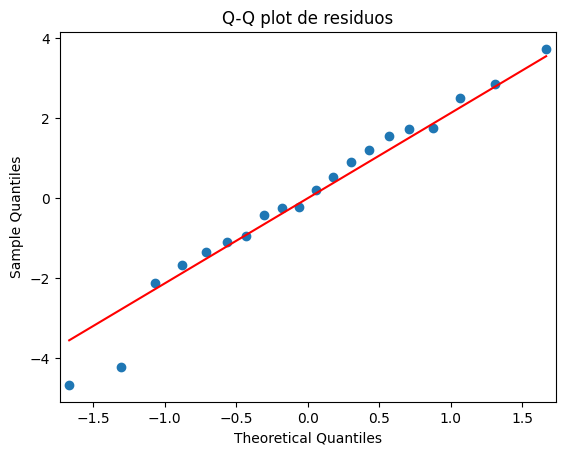

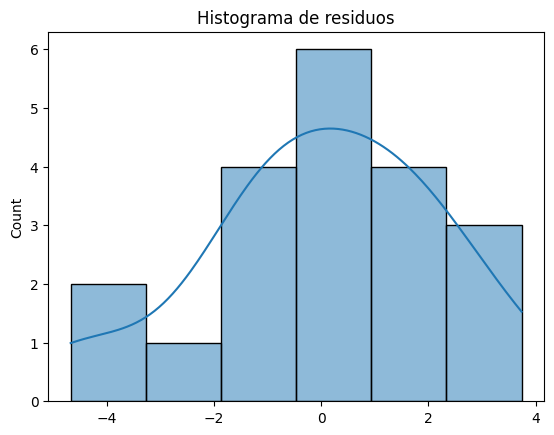

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_B = df[df['clona'] == 'C1']['azucar']
grupo_A = df[df['clona'] == 'C2']['azucar']
grupo_C = df[df['clona'] == 'C3']['azucar']
grupo_D = df[df['clona'] == 'C4']['azucar']



stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.7870
p-valor: 0.2181


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    C1     C2    4.886 0.0237   0.575  9.197   True
    C1     C3    8.056 0.0003   3.745 12.367   True
    C1     C4    0.842 0.9428  -3.469  5.153  False
    C2     C3     3.17 0.1939  -1.141  7.481  False
    C2     C4   -4.044 0.0699  -8.355  0.267  False
    C3     C4   -7.214  0.001 -11.525 -2.903   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

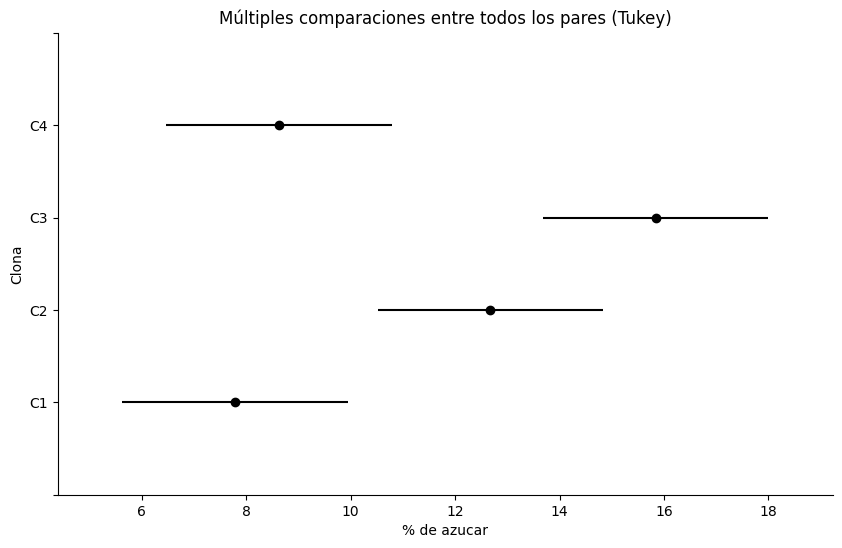

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['azucar'], # Variable de respuesta
    groups=df['clona'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Clona", xlabel="% de azucar")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["clona"]).mean()["azucar"]

,azucar
clona,
C1,7.786
C2,12.672
C3,15.842
C4,8.628


In [ ]:
from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(clona)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.698


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["clona"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.6980
f de Cohen = 1.5203
Potencia de la prueba = 0.9997


Conclusión:

Por medio de el test de Shapiro y Levene pudimos observar que se cumplen los supuestos de normalidad y homoscedasticidad, el primero con un valor de 0.7677 y el segundo con 0.2181.

Se observa que en la clona 1 se encuentra menos porcentaje de azúcar tanto en el tets de Tukey como en los promedios. De igual manera podemos notar que no hay una diferencia tan significativa con la clona 4 en cambio con las clonas 2 y 3 si se puede nnotar un poco más la diferencia.
Así que si se desea minimizar el nivel d eporcentaje de azucar el más recomendado es el 1 y como plan B el 4.


